# Lookback Uzunluğu Deneyi

Bu notebook, LSTM modeli için 10 ve 20 işlem günlük giriş pencerelerini validation döneminde karşılaştırır. Yalnızca lookback uzunluğu değiştirilir; veri bölünmesi, mimari, optimizer, epoch bütçesi ve seed sabit tutulur. Test dönemi kullanılmaz.

In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn
from torch.optim import Adam

from ms_stock_prediction.models import LSTMModel, count_trainable_parameters
from ms_stock_prediction.preprocessing import (
    PreparationConfig,
    load_close_prices,
    prepare_time_series,
)
from ms_stock_prediction.training import evaluate_loss, train_one_epoch

SEED = 42
LOOKBACKS = (10, 20)
EPOCHS = 100
LEARNING_RATE = 0.001
HIDDEN_SIZE = 32
NUM_LAYERS = 2
BATCH_SIZE = 32
DEVICE = torch.device("cpu")

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

## Kontrollü deney düzeni

Her lookback değeri için veri hattı ve DataLoader aynı seed ile yeniden oluşturulur. Model 100 epoch eğitilir ve en düşük validation kaybındaki ağırlıklar değerlendirilir. Validation hedef tarihleri aynı tutulduğu için iki pencere doğrudan karşılaştırılabilir.

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Proje kökü bulunamadı. Notebook'u proje içinde çalıştırın.")

DATA_PATH = PROJECT_ROOT / "data/raw/msft_daily_latest.csv"
prices = load_close_prices(DATA_PATH)

print(f"Kapanış fiyatı gözlemi: {len(prices):,}")
print(f"Tarih aralığı: {prices.index.min().date()} - {prices.index.max().date()}")

Kapanış fiyatı gözlemi: 4,156
Tarih aralığı: 2010-01-04 - 2026-07-14


In [3]:
def regression_metrics(actual, predicted):
    errors = predicted - actual
    mse = float(np.mean(errors**2))
    return {
        "MSE (USD²)": mse,
        "RMSE (USD)": float(np.sqrt(mse)),
        "MAE (USD)": float(np.mean(np.abs(errors))),
    }


def run_lookback_experiment(lookback):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    config = PreparationConfig(
        lookback=lookback,
        batch_size=BATCH_SIZE,
        shuffle_seed=SEED,
    )
    prepared = prepare_time_series(prices, config)
    model = LSTMModel(
        input_size=1,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        output_size=1,
    ).to(DEVICE)
    loss_function = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

    history = []
    best_validation_loss = float("inf")
    best_epoch = 0
    best_model_state = None
    training_started = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(
            model, prepared.train_loader, optimizer, loss_function, DEVICE
        )
        validation_loss = evaluate_loss(
            model, prepared.validation_loader, loss_function, DEVICE
        )
        history.append(
            {
                "Epoch": epoch,
                "Train MSE (scaled)": train_loss,
                "Validation MSE (scaled)": validation_loss,
            }
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Lookback {lookback:02d} | epoch {epoch:03d}/{EPOCHS} | "
                f"train={train_loss:.6f} | validation={validation_loss:.6f}"
            )

    training_seconds = time.perf_counter() - training_started
    if best_model_state is None:
        raise RuntimeError("Eğitim sırasında geçerli model ağırlığı üretilemedi.")

    model.load_state_dict(best_model_state)
    model.eval()
    with torch.no_grad():
        predicted_scaled = model(prepared.X_validation.to(DEVICE)).cpu().numpy()

    actual_scaled = prepared.y_validation.numpy()
    predicted_usd = prepared.scaler.inverse_transform(predicted_scaled).ravel()
    actual_usd = prepared.scaler.inverse_transform(actual_scaled).ravel()
    metrics = regression_metrics(actual_usd, predicted_usd)

    outcome = {
        "Lookback": lookback,
        "Train hedefi": len(prepared.y_train),
        "Validation hedefi": len(prepared.y_validation),
        "Seçilen epoch": best_epoch,
        **metrics,
        "Parametre": count_trainable_parameters(model),
        "Eğitim süresi (sn)": training_seconds,
    }

    return (
        prepared,
        pd.DataFrame(history).set_index("Epoch"),
        outcome,
        predicted_usd,
        actual_usd,
    )

## Eğitim çalışmaları

İki LSTM modeli birbirinden bağımsız ve aynı başlangıç koşullarıyla eğitilir.

In [4]:
experiment_artifacts = {}
outcomes = []

for lookback in LOOKBACKS:
    prepared, history, outcome, prediction, actual = run_lookback_experiment(lookback)
    experiment_artifacts[lookback] = {
        "prepared": prepared,
        "history": history,
        "prediction": prediction,
        "actual": actual,
    }
    outcomes.append(outcome)

reference_dates = experiment_artifacts[LOOKBACKS[0]]["prepared"].validation_target_dates
reference_actual = experiment_artifacts[LOOKBACKS[0]]["actual"]
for lookback in LOOKBACKS[1:]:
    assert reference_dates.equals(
        experiment_artifacts[lookback]["prepared"].validation_target_dates
    )
    assert np.array_equal(reference_actual, experiment_artifacts[lookback]["actual"])

Lookback 10 | epoch 001/100 | train=0.148484 | validation=0.402782


Lookback 10 | epoch 010/100 | train=0.000440 | validation=0.014876


Lookback 10 | epoch 020/100 | train=0.000433 | validation=0.011300


Lookback 10 | epoch 030/100 | train=0.000375 | validation=0.007771


Lookback 10 | epoch 040/100 | train=0.000327 | validation=0.003957


...

Lookback 20 | epoch 060/100 | train=0.000220 | validation=0.002237


Lookback 20 | epoch 070/100 | train=0.000212 | validation=0.002137


Lookback 20 | epoch 080/100 | train=0.000213 | validation=0.002292


Lookback 20 | epoch 090/100 | train=0.000211 | validation=0.001939


Lookback 20 | epoch 100/100 | train=0.000200 | validation=0.002186


In [5]:
results = pd.DataFrame(outcomes).sort_values("Lookback").reset_index(drop=True)
display(results)

reference_prepared = experiment_artifacts[LOOKBACKS[0]]["prepared"]
naive_scaled = reference_prepared.X_validation[:, -1, 0].numpy().reshape(-1, 1)
naive_usd = reference_prepared.scaler.inverse_transform(naive_scaled).ravel()
naive_metrics = regression_metrics(reference_actual, naive_usd)

print(
    f"Naive baseline | RMSE={naive_metrics['RMSE (USD)']:.4f} USD | "
    f"MAE={naive_metrics['MAE (USD)']:.4f} USD"
)

,Lookback,Train hedefi,Validation hedefi,Seçilen epoch,MSE (USD²),RMSE (USD),MAE (USD),Parametre,Eğitim süresi (sn)
0,10,2899,623,98,29.4775,5.4293,4.2726,12961,29.6248
1,20,2889,623,96,29.4468,5.4265,4.2340,12961,33.6979


Naive baseline | RMSE=4.9875 USD | MAE=3.7967 USD


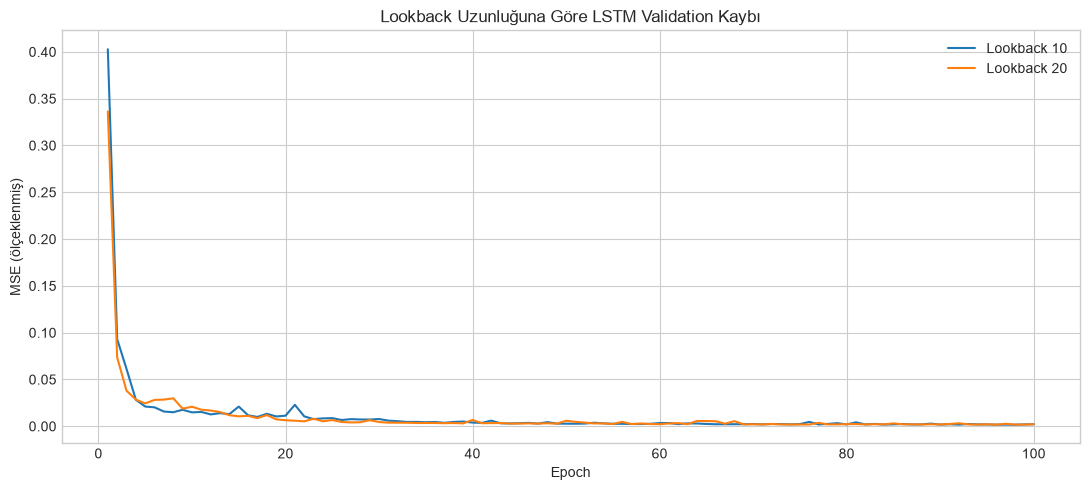

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
for lookback in LOOKBACKS:
    history = experiment_artifacts[lookback]["history"]
    history["Validation MSE (scaled)"].plot(
        ax=ax, label=f"Lookback {lookback}", linewidth=1.5
    )
ax.set_title("Lookback Uzunluğuna Göre LSTM Validation Kaybı")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (ölçeklenmiş)")
ax.legend()
plt.tight_layout()
plt.show()

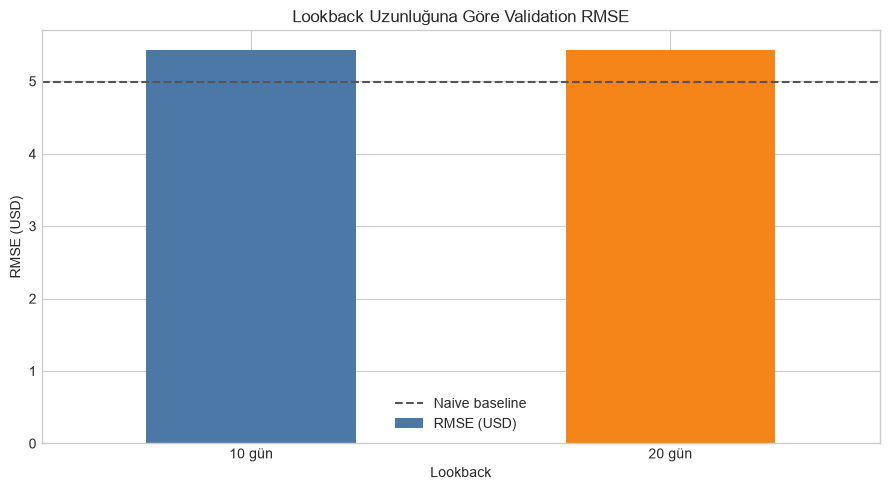

In [7]:
plot_results = results.set_index(results["Lookback"].map(lambda value: f"{value} gün"))
ax = plot_results["RMSE (USD)"].plot(
    kind="bar", figsize=(9, 5), rot=0, color=["#4C78A8", "#F58518"]
)
ax.axhline(
    naive_metrics["RMSE (USD)"],
    color="#555555",
    linestyle="--",
    label="Naive baseline",
)
ax.set_title("Lookback Uzunluğuna Göre Validation RMSE")
ax.set_xlabel("Lookback")
ax.set_ylabel("RMSE (USD)")
ax.legend()
plt.tight_layout()
plt.show()

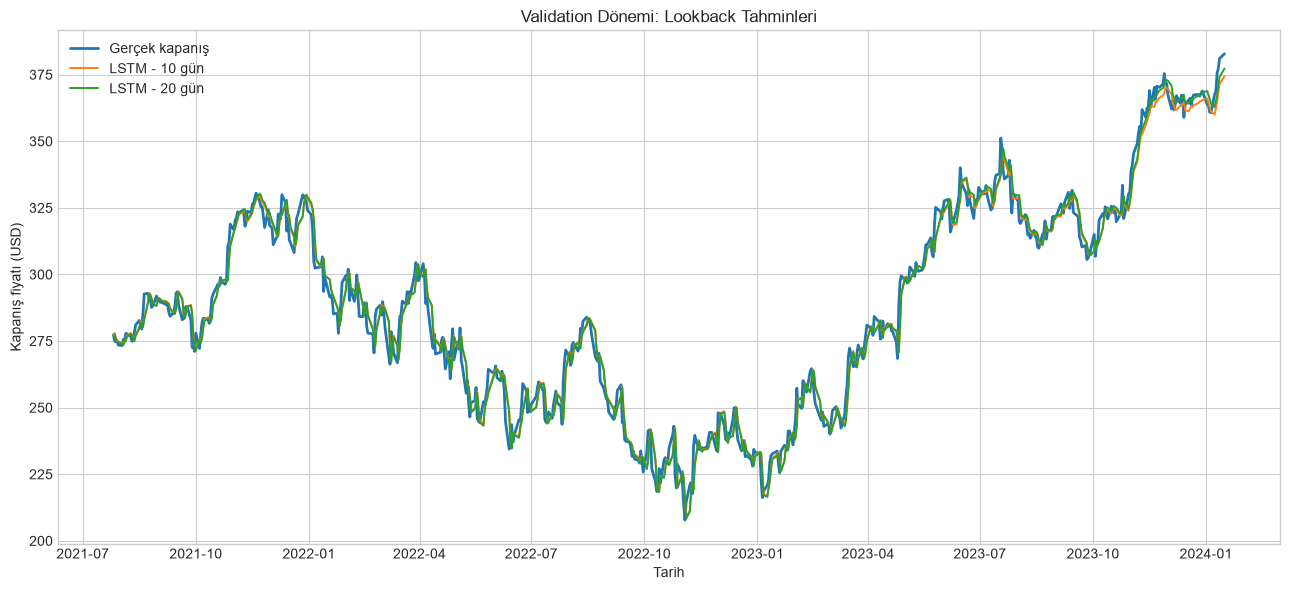

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(reference_dates, reference_actual, label="Gerçek kapanış", linewidth=2)
for lookback in LOOKBACKS:
    ax.plot(
        reference_dates,
        experiment_artifacts[lookback]["prediction"],
        label=f"LSTM - {lookback} gün",
        linewidth=1.4,
    )
ax.set_title("Validation Dönemi: Lookback Tahminleri")
ax.set_xlabel("Tarih")
ax.set_ylabel("Kapanış fiyatı (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Validation bulguları

Aşağıdaki özet, giriş penceresi uzunluğunun etkisini gösterir. Sonuçlar validation dönemine aittir ve test performansı değildir.

In [9]:
best_index = results["RMSE (USD)"].idxmin()
best_row = results.loc[best_index]
rmse_10 = results.loc[results["Lookback"] == 10, "RMSE (USD)"].iloc[0]
rmse_20 = results.loc[results["Lookback"] == 20, "RMSE (USD)"].iloc[0]

assert np.isfinite(results[["RMSE (USD)", "MAE (USD)"]].to_numpy()).all()
assert reference_dates.max() < reference_prepared.test_target_dates.min()

print(f"10 gün lookback RMSE: {rmse_10:.4f} USD")
print(f"20 gün lookback RMSE: {rmse_20:.4f} USD")
print(f"RMSE farkı (10 - 20): {rmse_10 - rmse_20:+.4f} USD")
print(
    f"En düşük LSTM validation RMSE: {int(best_row['Lookback'])} gün / "
    f"{best_row['RMSE (USD)']:.4f} USD"
)
print(f"Naive baseline validation RMSE: {naive_metrics['RMSE (USD)']:.4f} USD")
print("Test dönemine ait tahmin veya metrik hesaplanmadı.")

10 gün lookback RMSE: 5.4293 USD
20 gün lookback RMSE: 5.4265 USD
RMSE farkı (10 - 20): +0.0028 USD
En düşük LSTM validation RMSE: 20 gün / 5.4265 USD
Naive baseline validation RMSE: 4.9875 USD
Test dönemine ait tahmin veya metrik hesaplanmadı.
